In [1]:
# Install library yang dibutuhkan
%pip install -U segmentation-models-pytorch albumentations opencv-python matplotlib pandas numpy kagglehub scikit-learn

import os
import cv2
import torch
import torch.nn as nn
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split

# Set Device - Use GPU 0 (GTX 1050 Ti)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")
    print(f"✓ CUDA is available")
    print(f"✓ GPU Count: {torch.cuda.device_count()}")
    print(f"✓ Using GPU: {torch.cuda.get_device_name(0)}")
    print(f"✓ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    DEVICE = torch.device("cpu")
    print("✗ CUDA not available, using CPU")

print(f"Device: {DEVICE}\n")

# Download Dataset dari Kaggle
path = kagglehub.dataset_download("faizalkarim/flood-area-segmentation")
print(f"Dataset path: {path}")

IMAGE_DIR = os.path.join(path, "Image")
MASK_DIR = os.path.join(path, "Mask")
METADATA = os.path.join(path, "metadata.csv")

Note: you may need to restart the kernel to use updated packages.


c:\Users\ferdi\Development\notebook\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ CUDA is available
✓ GPU Count: 1
✓ Using GPU: NVIDIA GeForce GTX 1050 Ti
✓ GPU Memory: 4.29 GB
Device: cuda:0

Dataset path: C:\Users\ferdi\.cache\kagglehub\datasets\faizalkarim\flood-area-segmentation\versions\1


In [2]:
class FloodDataset(Dataset):
    def __init__(self, df, img_dir, mask_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        try:
            img_name = self.df.iloc[idx, 0]
            mask_name = self.df.iloc[idx, 1]

            image = cv2.imread(os.path.join(self.img_dir, img_name))
            mask = cv2.imread(os.path.join(self.mask_dir, mask_name), cv2.IMREAD_GRAYSCALE)

            if image is None or mask is None:
                raise ValueError(f"Skipping broken file: {img_name}")

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # RESIZE PAKSA ke 512x384 (Kelipatan 32 untuk DeepLabV3+)
            image = cv2.resize(image, (512, 384))
            mask = cv2.resize(mask, (512, 384), interpolation=cv2.INTER_NEAREST)
            mask = (mask > 127).astype(np.float32)

            if self.transform:
                augmented = self.transform(image=image, mask=mask)
                image = augmented['image']
                mask = augmented['mask'].unsqueeze(0)

            return image, mask
        except Exception as e:
            # Jika ada file rusak, ambil data index 0 sebagai cadangan
            return self.__getitem__(0)

# Transformasi tanpa A.Resize (karena sudah di-resize manual di atas)
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], is_check_shapes=False)

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], is_check_shapes=False)

In [3]:
# Split Data
df = pd.read_csv(METADATA)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

train_loader = DataLoader(FloodDataset(train_df, IMAGE_DIR, MASK_DIR, train_transform), batch_size=8, shuffle=True)
val_loader = DataLoader(FloodDataset(val_df, IMAGE_DIR, MASK_DIR, val_transform), batch_size=8, shuffle=False)

# Build DeepLabV3+
model = smp.DeepLabV3Plus(
    encoder_name='resnet50',
    encoder_weights='imagenet',
    classes=1,
    activation=None
).to(DEVICE)

# Cek apakah checkpoint sudah ada, jika ada load langsung tanpa train ulang
if os.path.exists('deeplab_checkpoint.pth'):
    print("✓ Loading model dari checkpoint yang ada...")
    model.load_state_dict(torch.load('deeplab_checkpoint.pth', map_location=DEVICE))
    model.eval()
    print("✓ Model loaded dan siap digunakan!")
else:
    print("✗ Checkpoint tidak ditemukan, model akan ditraining dari awal")

# Loss Gabungan (Custom Function)
dice_loss = smp.losses.DiceLoss(mode='binary')
bce_loss = nn.BCEWithLogitsLoss()

def criterion(preds, targets):
    return dice_loss(preds, targets) + bce_loss(preds, targets)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

✓ Loading model dari checkpoint yang ada...
✓ Model loaded dan siap digunakan!


In [4]:
def calculate_iou(preds, masks):
    preds = (torch.sigmoid(preds) > 0.5).float()
    intersection = (preds * masks).sum()
    union = preds.sum() + masks.sum() - intersection
    return (intersection / (union + 1e-8)).item()

# Cek apakah model sudah di-load dari checkpoint
if os.path.exists('deeplab_checkpoint.pth') and model.training == False:
    print("✓ Model sudah di-load dari checkpoint, skip training")
    print("✓ Lanjut ke evaluasi...")
else:
    print("Training model...")
    EPOCHS = 20
    for epoch in range(EPOCHS):
        model.train()
        t_iou = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
        for imgs, msks in pbar:
            imgs, msks = imgs.to(DEVICE), msks.to(DEVICE)

            optimizer.zero_grad()
            output = model(imgs)
            loss = criterion(output, msks)
            loss.backward()
            optimizer.step()

            t_iou += calculate_iou(output, msks)
            pbar.set_postfix({'IoU': t_iou/(pbar.n+1)})

        # Simpan bobot tiap epoch sebagai checkpoint
        torch.save(model.state_dict(), 'deeplab_checkpoint.pth')

✓ Model sudah di-load dari checkpoint, skip training
✓ Lanjut ke evaluasi...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.08956].


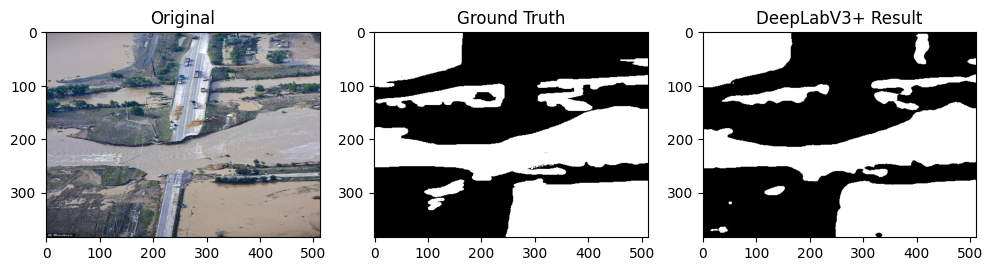

In [5]:
model.eval()
imgs, msks = next(iter(val_loader))
with torch.no_grad():
    preds = torch.sigmoid(model(imgs.to(DEVICE))).cpu()

plt.figure(figsize=(12, 4))
plt.subplot(1,3,1); plt.imshow(imgs[0].permute(1,2,0).numpy() * 0.229 + 0.485); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(msks[0][0], cmap='gray'); plt.title("Ground Truth")
plt.subplot(1,3,3); plt.imshow(preds[0][0] > 0.5, cmap='gray'); plt.title("DeepLabV3+ Result")
plt.show()

In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_model(model, dataloader, device):
    model.eval()
    ious, precisions, recalls, f1s = [], [], [], []

    print("Sedang mengevaluasi pada dataset validasi...")
    with torch.no_grad():
        for imgs, msks in tqdm(dataloader):
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = (torch.sigmoid(outputs) > 0.5).float().cpu().numpy().flatten()
            targets = msks.numpy().flatten()

            # Kalkulasi per batch
            ious.append(calculate_iou(outputs.cpu(), msks))
            precisions.append(precision_score(targets, preds, zero_division=1))
            recalls.append(recall_score(targets, preds, zero_division=1))
            f1s.append(f1_score(targets, preds, zero_division=1))

    results = {
        "Mean IoU": np.mean(ious),
        "Precision": np.mean(precisions),
        "Recall": np.mean(recalls),
        "F1-Score": np.mean(f1s)
    }
    return results

# Eksekusi Evaluasi
metrics_deeplab = evaluate_model(model, val_loader, DEVICE)

# Tampilkan Tabel
df_results = pd.DataFrame([metrics_deeplab], index=['DeepLabV3+ (ResNet50)'])
print("\n", df_results)

Sedang mengevaluasi pada dataset validasi...


100%|██████████| 8/8 [00:08<00:00,  1.07s/it]


                        Mean IoU  Precision    Recall  F1-Score
DeepLabV3+ (ResNet50)  0.821745    0.89691  0.906991  0.901559
